In [ ]:
PROCESSED_PATH = DATA_DIR / "telco_student_processed.csv"

if not PROCESSED_PATH.exists():
    raise FileNotFoundError(
        f"İşlenmiş veri seti bulunamadı: {PROCESSED_PATH}\n"
    )

df_model = pd.read_csv(PROCESSED_PATH)

print("İşlenmiş veri seti yüklendi.")
print("Veri boyutu:", df_model.shape)

df_model.head()

İşlenmiş veri seti yüklendi.
Veri boyutu: (7043, 26)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaymentMethod,MonthlyCharges,TotalCharges,Churn,AvgMonthlyCharge,HasInternetService,AutomaticPayment,IsMonthToMonth,NumInternetServices,TenureGroup
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,Electronic check,29.85,29.85,0,29.850000,1,0,1,1,0-12
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,Mailed check,56.95,1889.50,0,55.573529,1,0,0,2,25-48
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,Mailed check,53.85,108.15,1,54.075000,1,0,1,2,0-12
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Bank transfer (automatic),42.30,1840.75,0,40.905556,1,1,0,3,25-48
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,Electronic check,70.70,151.65,1,75.825000,1,0,1,0,0-12


In [3]:
X = df_model.drop(columns=["Churn"])
y = df_model["Churn"]

print("X boyutu:", X.shape)
print("y boyutu:", y.shape)
print("Churn oranı:", round(y.mean(), 4))

X boyutu: (7043, 25)
y boyutu: (7043,)
Churn oranı: 0.2654


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train churn oranı:", round(y_train.mean(), 4))
print("y_test churn oranı :", round(y_test.mean(), 4))

X_train: (5634, 25)
X_test : (1409, 25)
y_train churn oranı: 0.2654
y_test churn oranı : 0.2654


In [5]:
numeric_features = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Sayısal değişkenler:")
print(numeric_features)

print("\nKategorik değişkenler:")
print(categorical_features)

Sayısal değişkenler:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AvgMonthlyCharge', 'HasInternetService', 'AutomaticPayment', 'IsMonthToMonth', 'NumInternetServices']

Kategorik değişkenler:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup']


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

pipelines = {}

for model_name, model in models.items():
    pipelines[model_name] = Pipeline(
        steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ]
    )

pipelines

{'Logistic Regression': Pipeline(steps=[('preprocess',
                  ColumnTransformer(transformers=[('num', StandardScaler(),
                                                   ['SeniorCitizen', 'tenure',
                                                    'MonthlyCharges',
                                                    'TotalCharges',
                                                    'AvgMonthlyCharge',
                                                    'HasInternetService',
                                                    'AutomaticPayment',
                                                    'IsMonthToMonth',
                                                    'NumInternetServices']),
                                                  ('cat',
                                                   OneHotEncoder(drop='first',
                                                                 handle_unknown='ignore'),
                                                   ['gender

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc"
}

cv_results = []

for model_name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    row = {"Model": model_name}

    for metric in scoring.keys():
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)
cv_results_df = cv_results_df.sort_values("roc_auc_mean", ascending=False)

cv_results_df.to_csv(TABLE_DIR / "01_cross_validation_results.csv", index=False)

cv_results_df.round(4)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
1,Random Forest,0.7604,0.0100,0.5333,0.0134,0.7819,0.0214,0.6340,0.0128,0.8479,0.0112
2,Gradient Boosting,0.7980,0.0104,0.6552,0.0375,0.5104,0.0143,0.5730,0.0125,0.8461,0.0117
0,Logistic Regression,0.7490,0.0135,0.5177,0.0168,0.7967,0.0352,0.6274,0.0209,0.8458,0.0112


In [9]:
test_results = []
trained_pipelines = {}

for model_name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    trained_pipelines[model_name] = pipe

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    row = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    test_results.append(row)

test_results_df = pd.DataFrame(test_results)
test_results_df = test_results_df.sort_values("ROC_AUC", ascending=False)

test_results_df.to_csv(TABLE_DIR / "02_test_results.csv", index=False)

test_results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
1,Random Forest,0.7644,0.5380,0.7941,0.6415,0.8451
2,Gradient Boosting,0.8041,0.6701,0.5160,0.5831,0.8433
0,Logistic Regression,0.7331,0.4983,0.7914,0.6116,0.8420


In [10]:
best_model_name = test_results_df.iloc[0]["Model"]
best_model = trained_pipelines[best_model_name]

print("En iyi model:", best_model_name)

En iyi model: Random Forest



Logistic Regression


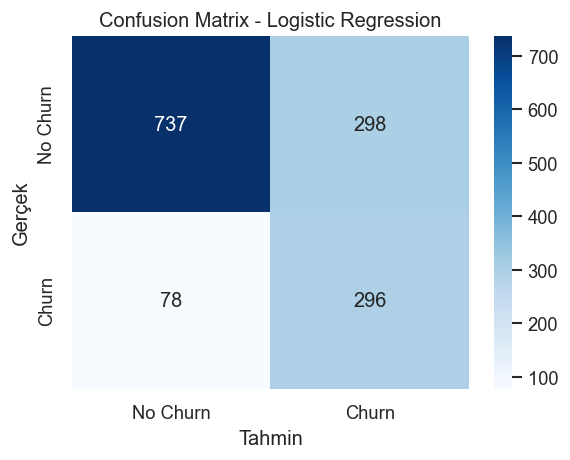

              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1035
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1409
   macro avg       0.70      0.75      0.70      1409
weighted avg       0.80      0.73      0.75      1409


Random Forest


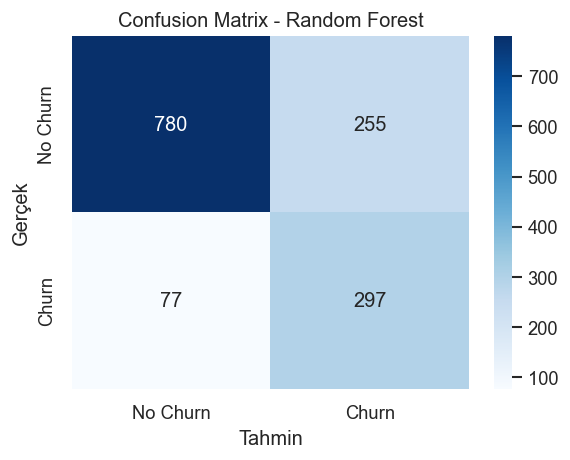

              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.54      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.78      1409


Gradient Boosting


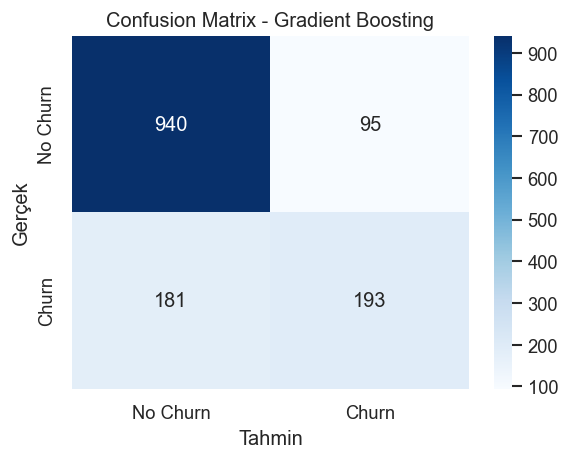

              precision    recall  f1-score   support

    No Churn       0.84      0.91      0.87      1035
       Churn       0.67      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



In [11]:
def plot_confusion_matrix_for_model(model_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Tahmin")
    plt.ylabel("Gerçek")
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"01_confusion_matrix_{model_name.replace(' ', '_')}.png")
    plt.show()

    print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


for model_name, model in trained_pipelines.items():
    print("\n" + "="*80)
    print(model_name)
    plot_confusion_matrix_for_model(model_name, model, X_test, y_test)

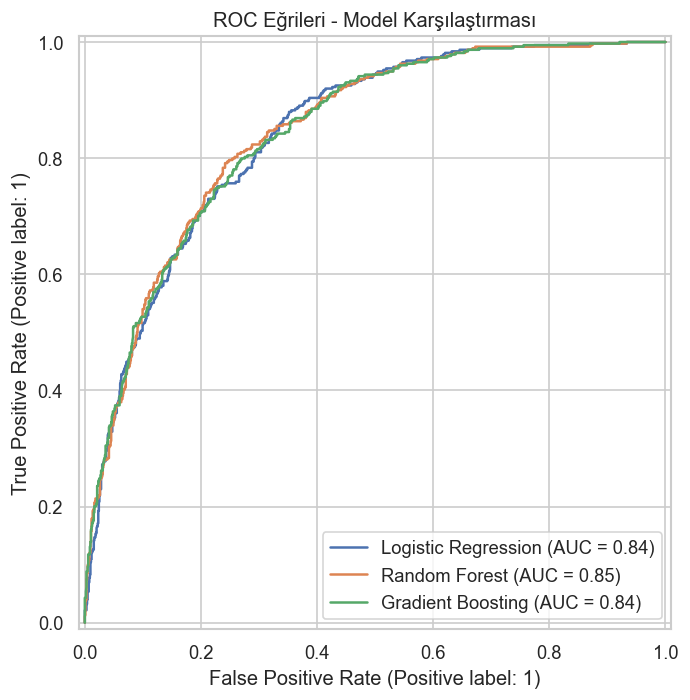

In [12]:
plt.figure(figsize=(8, 6))

ax = plt.gca()

for model_name, model in trained_pipelines.items():
    RocCurveDisplay.from_estimator(
        model,
        X_test,
        y_test,
        ax=ax,
        name=model_name
    )

plt.title("ROC Eğrileri - Model Karşılaştırması")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_roc_curves.png")
plt.show()

In [13]:
y_prob_best = best_model.predict_proba(X_test)[:, 1]

threshold_rows = []

for threshold in np.arange(0.30, 0.71, 0.05):
    y_pred_threshold = (y_prob_best >= threshold).astype(int)

    threshold_rows.append({
        "threshold": round(threshold, 2),
        "precision": precision_score(y_test, y_pred_threshold),
        "recall": recall_score(y_test, y_pred_threshold),
        "f1": f1_score(y_test, y_pred_threshold),
        "accuracy": accuracy_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.to_csv(TABLE_DIR / "03_threshold_analysis.csv", index=False)

threshold_df.round(4)

,threshold,precision,recall,f1,accuracy
0,0.30,0.4391,0.9064,0.5916,0.6678
1,0.35,0.4528,0.8717,0.5960,0.6863
2,0.40,0.4812,0.8556,0.6160,0.7168
3,0.45,0.5109,0.8155,0.6282,0.7438
4,0.50,0.5380,0.7941,0.6415,0.7644
5,0.55,0.5510,0.7513,0.6357,0.7715
6,0.60,0.5807,0.6925,0.6317,0.7857
7,0.65,0.6111,0.6176,0.6144,0.7942
8,0.70,0.6580,0.5401,0.5932,0.8034


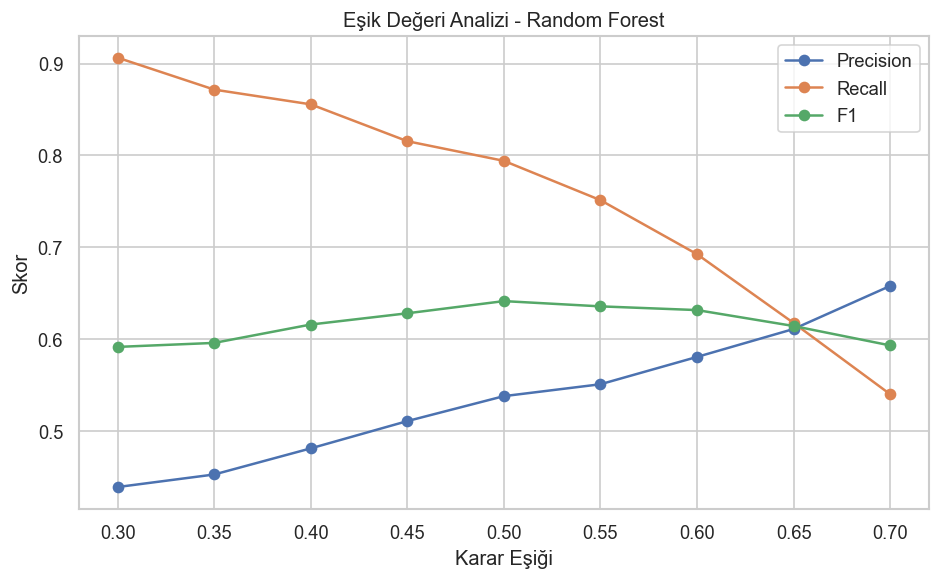

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="F1")

plt.title(f"Eşik Değeri Analizi - {best_model_name}")
plt.xlabel("Karar Eşiği")
plt.ylabel("Skor")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_threshold_analysis.png")
plt.show()

In [15]:
perm_result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

importance_df.to_csv(TABLE_DIR / "04_permutation_importance.csv", index=False)

importance_df.head(15)

,feature,importance_mean,importance_std
22,IsMonthToMonth,0.030851,0.003090
4,tenure,0.023565,0.002088
7,InternetService,0.017034,0.004871
18,TotalCharges,0.010319,0.001423
14,Contract,0.010042,0.001472
16,PaymentMethod,0.002842,0.001142
24,TenureGroup,0.002563,0.000797
19,AvgMonthlyCharge,0.001501,0.001938
8,OnlineSecurity,0.001133,0.000818
17,MonthlyCharges,0.001043,0.002053


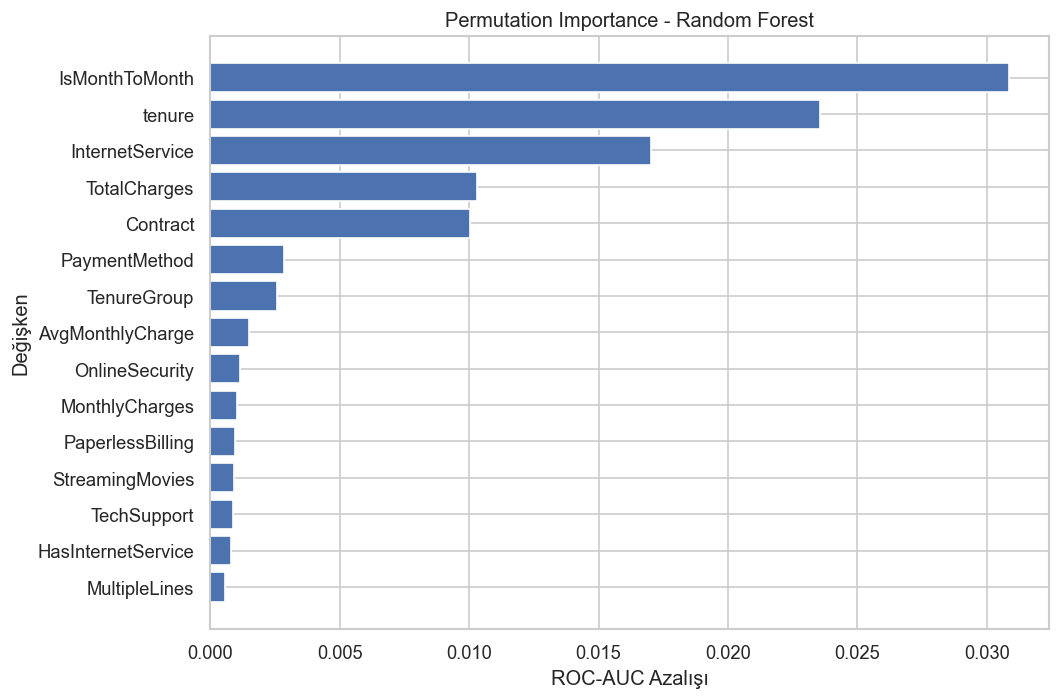

In [16]:
top_importance = importance_df.head(15).sort_values("importance_mean", ascending=True)

plt.figure(figsize=(9, 6))
plt.barh(top_importance["feature"], top_importance["importance_mean"])
plt.title(f"Permutation Importance - {best_model_name}")
plt.xlabel("ROC-AUC Azalışı")
plt.ylabel("Değişken")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_permutation_importance.png")
plt.show()

In [17]:
model_path = MODEL_DIR / "best_telco_churn_model.joblib"
joblib.dump(best_model, model_path)

print("Model kaydedildi:", model_path)

Model kaydedildi: C:\Users\ferha\Desktop\telco-churn-analysis v2\outputs\models\best_telco_churn_model.joblib


In [18]:
sample_customer = X_test.iloc[[0]]
sample_probability = best_model.predict_proba(sample_customer)[:, 1][0]
sample_prediction = best_model.predict(sample_customer)[0]

print("Örnek müşteri için churn olasılığı:", round(sample_probability, 4))
print("Tahmin edilen sınıf:", "Churn" if sample_prediction == 1 else "No Churn")

sample_customer

Örnek müşteri için churn olasılığı: 0.0584
Tahmin edilen sınıf: No Churn


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,AvgMonthlyCharge,HasInternetService,AutomaticPayment,IsMonthToMonth,NumInternetServices,TenureGroup
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,...,Yes,Credit card (automatic),114.05,8468.2,117.613889,1,1,0,6,49-72
